In [10]:
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
font_path = 'C:/Windows/Fonts/malgun.ttf'
font_prop = fm.FontProperties(fname=font_path, size=12)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

import pandas as pd

In [5]:
# 데이터 불러오기
df = pd.read_csv('../data/Indian_Traffic_Violations.csv', low_memory=False)

df.shape, df.columns

((4000, 33),
 Index(['Violation_ID', 'Violation_Type', 'Fine_Amount', 'Location', 'Date',
        'Time', 'Vehicle_Type', 'Vehicle_Color', 'Vehicle_Model_Year',
        'Registration_State', 'Driver_Age', 'Driver_Gender', 'License_Type',
        'Penalty_Points', 'Weather_Condition', 'Road_Condition', 'Officer_ID',
        'Issuing_Agency', 'License_Validity', 'Number_of_Passengers',
        'Helmet_Worn', 'Seatbelt_Worn', 'Traffic_Light_Status', 'Speed_Limit',
        'Recorded_Speed', 'Alcohol_Level', 'Breathalyzer_Result', 'Towed',
        'Fine_Paid', 'Payment_Method', 'Court_Appearance_Required',
        'Previous_Violations', 'Comments'],
       dtype='object'))

In [21]:
df.head()

,Violation_ID,Violation_Type,Fine_Amount,Location,Date,Time,Vehicle_Type,Vehicle_Color,Vehicle_Model_Year,Registration_State,...,Alcohol_Level,Breathalyzer_Result,Towed,Fine_Paid,Payment_Method,Court_Appearance_Required,Previous_Violations,Comments,Overspeed,Cluster
0,VLT100000,Overloading,4544,Karnataka,2023-01-01,23:02,Car,Red,2012,West Bengal,...,0.03,Negative,Yes,No,Online,Yes,3,Repeat Offender,False,1
1,VLT100001,Driving Without License,2776,Punjab,2023-01-02,00:42,Scooter,Silver,2010,Tamil Nadu,...,0.45,Negative,Yes,Yes,Online,No,2,Repeat Offender,True,2
2,VLT100002,Using Mobile Phone,4785,Maharashtra,2023-01-03,04:32,Scooter,Grey,2006,Tamil Nadu,...,0.31,Not Conducted,No,No,Not Paid,Yes,4,NaN,False,0
3,VLT100003,No Seatbelt,1138,Uttar Pradesh,2023-01-04,15:06,Car,Green,1996,Uttar Pradesh,...,0.09,Not Conducted,No,Yes,Online,No,5,Repeat Offender,True,1
4,VLT100004,Over-speeding,1610,Karnataka,2023-01-05,06:57,Truck,Yellow,2016,Delhi,...,0.28,Positive,No,Yes,Cash,Yes,0,NaN,True,1


In [6]:
# 속도 파생 변수
df['Overspeed'] = df['Recorded_Speed'] > df['Speed_Limit']

In [7]:
# 변수 선택
features = [
    'Recorded_Speed', 'Alcohol_Level', 'Overspeed',
    'License_Validity', 'Breathalyzer_Result', 'Traffic_Light_Status'
]

In [11]:
# 문자열 및 bool 열 인코딩
df_encoded = df.copy()

# object 타입 열을 Label Encoding
label_cols = df_encoded.select_dtypes(include='object').columns
for col in label_cols:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])
    
# bool 타입도 int로 변환
df_encoded['Overspeed'] = df_encoded['Overspeed'].astype(int)

In [13]:
# t-SNE 적용 (차원 축소)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(df_encoded[features])

# KMeans 클러스터링 적용
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(tsne_result)

In [14]:
# 결과 정리
tsne_df = pd.DataFrame(tsne_result, columns=['TSNE1', 'TSNE2'])
tsne_df['Cluster'] = kmeans_labels

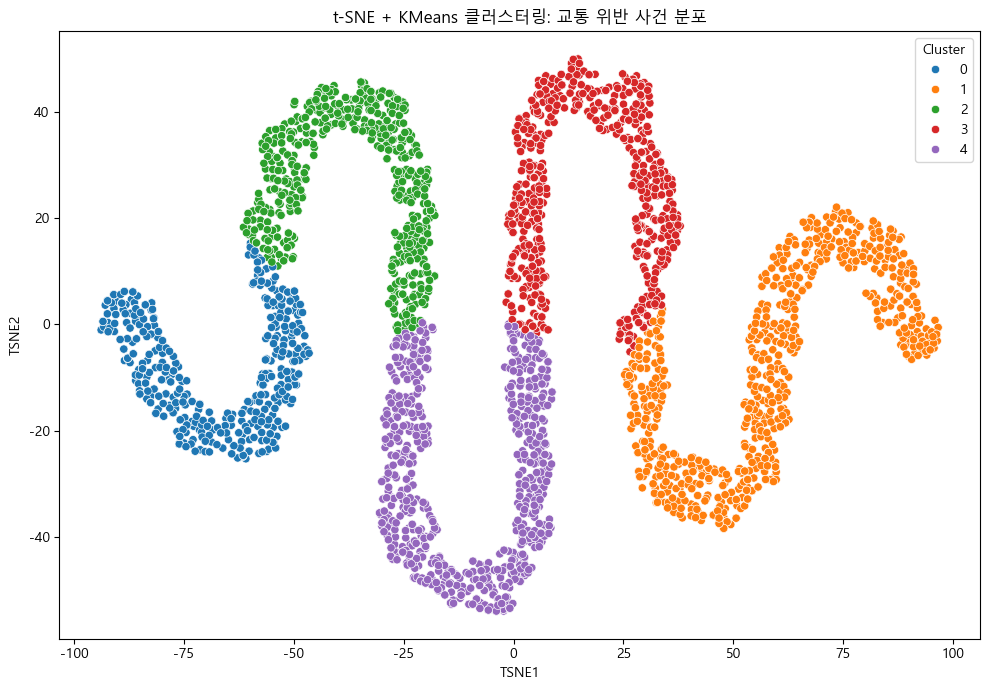

In [15]:
# 시각화
plt.figure(figsize=(10,7))
sns.scatterplot(
    x='TSNE1', y='TSNE2',
    hue='Cluster',
    palette='tab10',
    data=tsne_df,
    legend='full'
)
plt.title('t-SNE + KMeans 클러스터링: 교통 위반 사건 분포')
plt.tight_layout()
plt.show()

In [ ]:
# 수치형 열만 필터링해서 클러스터별 평균 계산
numeric_features = df[features].select_dtypes(include=['number']).columns
df.groupby('Cluster')[numeric_features].mean()
pd.crosstab(df['Cluster'], df['Violation_Type'])

Violation_Type,Driving Without License,Drunk Driving,No Helmet,No Seatbelt,Over-speeding,Overloading,Signal Jumping,Using Mobile Phone,Wrong Parking
Cluster,,,,,,,,,
0,71,77,67,70,64,74,73,67,75
1,126,145,122,117,117,108,122,110,118
2,88,80,80,71,78,65,75,56,80
3,73,89,97,88,81,67,81,86,100
4,93,97,97,94,108,85,95,92,81


- Cluster 0: 위반이 적은 저위험 집단
- Cluster 1: 고위험 운전자 집단일 가능성
- Cluster 2: 위반 빈도가 낮은 보통 수준의 집단
- Cluster 3: 운전 중 부주의 및 주차 위반이 많은 집단
- Cluster 4: 과속 및 보호장비 미착용이 특징인 집단

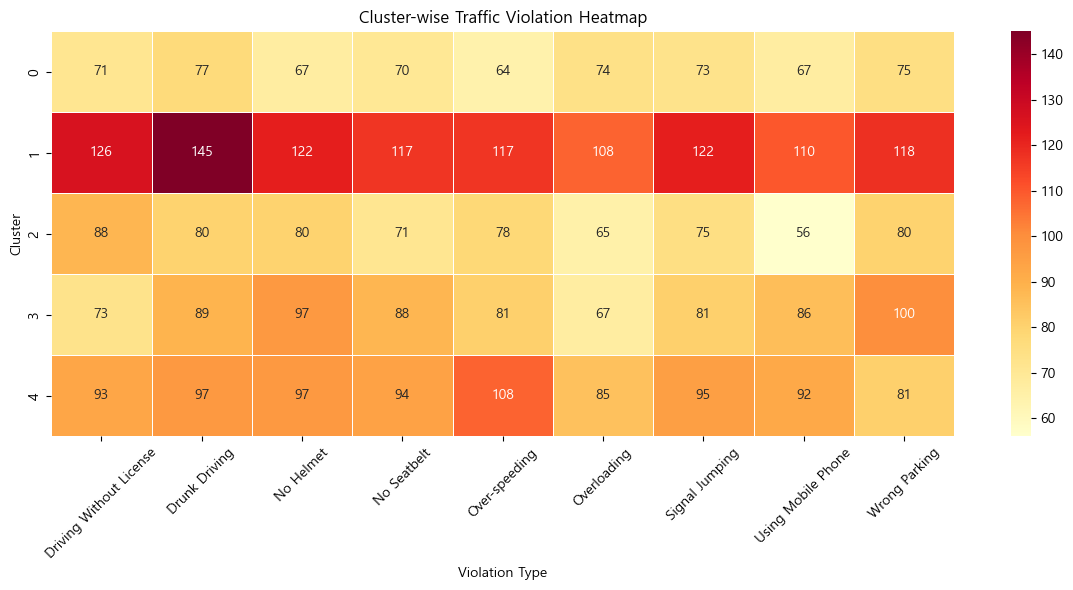

In [20]:
violation_matrix = pd.crosstab(df['Cluster'], df['Violation_Type'])

plt.figure(figsize=(12, 6))
sns.heatmap(violation_matrix, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Cluster-wise Traffic Violation Heatmap')
plt.xlabel('Violation Type')
plt.ylabel('Cluster')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
def classify_time_period(time_str):
    hour = int(time_str.split(':')[0])
    if 0 <= hour < 6:
        return '새벽'
    elif 6 <= hour < 12:
        return '오전'
    elif 12 <= hour < 18:
        return '오후'
    elif 18 <= hour < 21:
        return '저녁'
    else:
        return '밤'

# 시간대 열 추가
df['Time_Period'] = df['Time'].apply(classify_time_period)

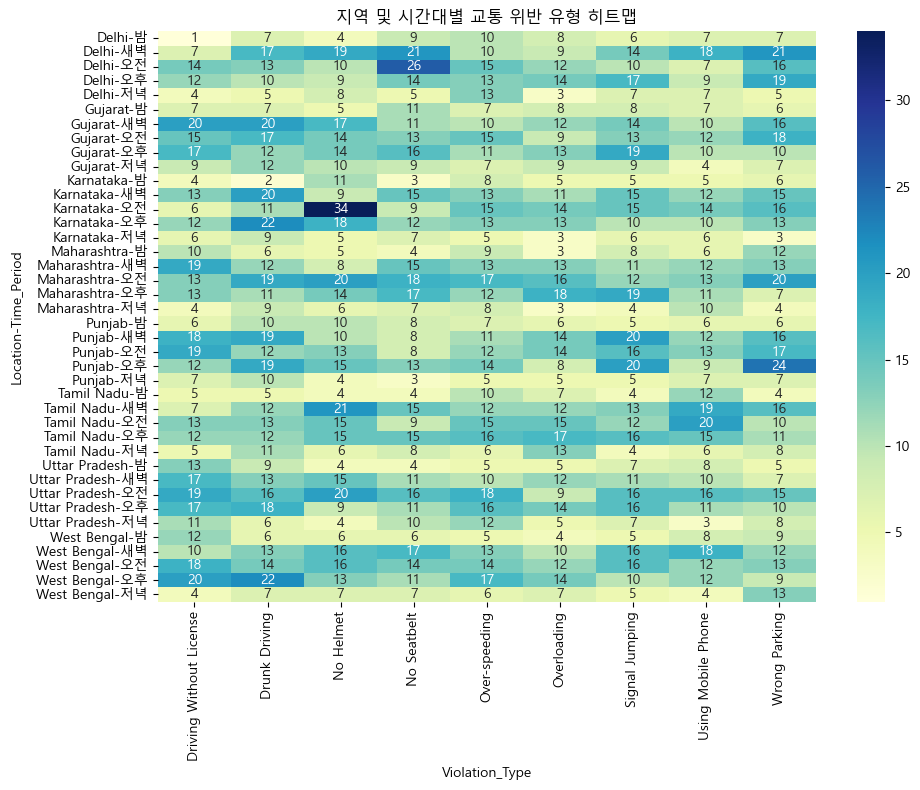

In [28]:
# 지역 + 시간대 조합별 위반 유형 히트맵
heatmap_data = df.groupby(['Location', 'Time_Period'])['Violation_Type'].value_counts().unstack().fillna(0)
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGnBu')
plt.title('지역 및 시간대별 교통 위반 유형 히트맵')
plt.tight_layout()
plt.show()